<a href="https://colab.research.google.com/github/Shahrukh2016/LangChain_LangGraph_LangSmith_Revision/blob/main/2_Revision_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get update -qq && sudo apt-get install -y zstd -qq
!curl -fsSLs https://ollama.com/install.sh | sh
!nohup ollama serve > ollama.log 2>&1 &
!ollama pull llama3.2:1b
!ollama pull llama3.1
# !ollama pull qwen:0.5b
!ollama pull qwen3-embedding:0.6b

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ol

In [2]:
!ollama ls

NAME                    ID              SIZE      MODIFIED               
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    Less than a second ago    
llama3.1:latest         46e0c10c039e    4.9 GB    9 seconds ago             
llama3.2:1b             baf6a787fdff    1.3 GB    About a minute ago        


In [5]:
!pip install -q langchain langchain-core langchain-classic langchain-huggingface langchain-ollama langchain-community langchain-ollama pydantic pydantic[email] grandalf pypdf pymupdf langchain_text_splitters langchain-experimental langchain-chroma chromadb --upgrade opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp langchain-pinecone langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.

# 1. LangGraph:

#### 1.1 BMI Calculator

In [ ]:
#### 1.1 BMI Calculator
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [ ]:
## Define state
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float

In [ ]:
## defining python function that runs while executing node
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state["weight_kg"]
  height = state["height_m"]
  bmi = weight/(height)**2
  state['bmi'] = round(bmi,2)
  return state

In [ ]:
## Define graph
graph = StateGraph(BMIState)

## Add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)

## Add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

## Compile the graph
workflow = graph.compile()

In [ ]:
# Execute the graph
initial_state = {"weight_kg" : 80, "height_m" : 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12}


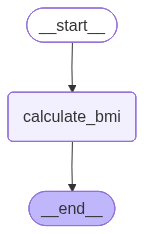

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.2 BMI Labellor

In [ ]:
#### 1.1 BMI Calculator
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Define state
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float
  category: str

## defining python function that runs while executing node
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state["weight_kg"]
  height = state["height_m"]
  bmi = weight/(height)**2
  state['bmi'] = round(bmi,2)
  return state

def calculate_label(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi < 18.5:
    state ["category"] = "Underweight"
  elif 18.5 <= bmi < 25:
    state["category"] = "Normal"
  elif 25 <= bmi < 30:
    state["category"] = "Overweight"
  else:
    state["category"] = "Obese"
  return state

## Define graph
graph = StateGraph(BMIState)

## Add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("calculate_label", calculate_label)


## Add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'calculate_label')
graph.add_edge('calculate_bmi', END)

## Compile the graph
workflow = graph.compile()


In [ ]:
# Execute the graph
initial_state = {"weight_kg" : 80, "height_m" : 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'category': 'Overweight'}


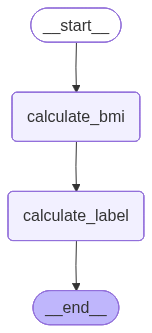

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.3 LLM QnA

In [ ]:
#### 1.3 Import
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Initialting the llm
model = ChatOllama(model = 'llama3.2:1b')

## Define state
class LLMQnA(TypedDict):
  question: str
  answer: str

## define function
def reply(state:LLMQnA) -> LLMQnA:
  question = state['question']
  answer = model.invoke(question).content
  state['answer'] = answer
  return state

## Define graph
graph = StateGraph(LLMQnA)

## Add nodes to the graph
graph.add_node("QnA", reply)

## Add edges to the graph
graph.add_edge(START, 'QnA')
graph.add_edge('QnA', END)

## Compile the graph
workflow = graph.compile()


In [ ]:
# Execute the graph
initial_state = {"question" : "What is the capital of India?"}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

The capital of India is New Delhi.


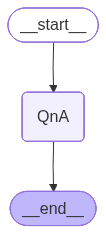

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.4 Prompt Chaining

In [ ]:
#### 1.3 Import
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Initialting the llm
model = ChatOllama(model = 'llama3.2:1b')

## Define state
class BlogState(TypedDict):
  title: str
  outline: str
  content: str

## define function
def create_outline(state: BlogState) -> BlogState:
  title = state['title']
  prompt = f'Generate a detailed outline for a blog on the topic - {title}'
  outline = model.invoke(prompt).content
  state['outline'] = outline
  return state

def create_blog(state: BlogState) -> BlogState:
  title = state['title']
  outline = state['outline']
  prompt = f'Generate a detailed blog for a given outline - {outline}'
  content = model.invoke(prompt).content
  state['content'] = content
  return state

## Define graph
graph = StateGraph(BlogState)

## Add nodes to the graph
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

## Add edges to the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

## Compile the graph
workflow = graph.compile()


In [ ]:
# Execute the graph
initial_state = {"title" : "Blackhole"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Blackhole', 'outline': "Here's a detailed outline for a blog on the topic of black holes:\n\n**I. Introduction**\n\n* Definition and explanation of what a black hole is\n* Importance of understanding black holes in astronomy and astrophysics\n* Brief overview of the purpose and scope of the blog post\n\n**II. What is a Black Hole?**\n\n* Explanation of the formation of black holes through supernovae explosions and stellar collapse\n* Description of the different types of black holes (stellar, supermassive, intermediate-mass)\n* Discussion of the events that occur near a black hole, such as accretion disks and jets\n\n**III. Characteristics of Black Holes**\n\n* Mass and size: how they relate to their event horizon radius and singularity\n* Spin: its effect on the behavior of matter and energy in the vicinity of the black hole\n* Temperature and density: what values are typical for different types of black holes\n* Event horizon and ergosphere: what they are and how they affe

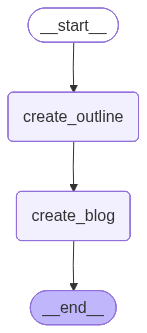

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.5 Non LLM Parallel Workflow

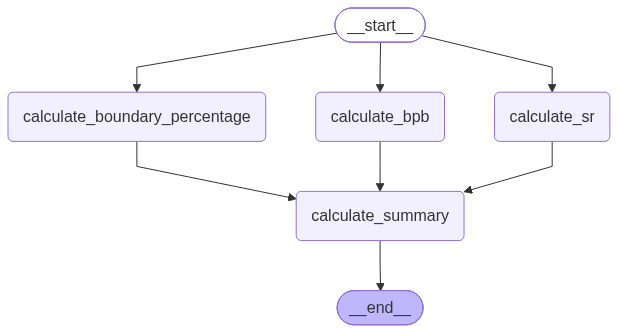

In [11]:
#### 1.5 Import
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


#### Definig state
class BatsmanState(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  sr: float
  bpb: float
  boundary_percentage: float
  summary: str


#### Defining functions
def calculate_sr(state: BatsmanState):
  sr = (state['runs']/state['balls'])*100
  return {'sr' : sr}

def calculate_bpb(state: BatsmanState):
  bpb = state['balls']/(state['fours']+state['sixes'])
  return {'bpb' : bpb}

def calculate_boundary_percentage(state: BatsmanState):
  boundary_percentage = ((state['fours']*4)+(state['sixes']*6)/state['runs'])*100
  return {'boundary_percentage': boundary_percentage}

def calculate_summary(state: BatsmanState):
  summary = f'''
  Strike rate: {state['sr']}\n
  Balls per boundary: {state['bpb']}\n
  Boundary percentage: {state['boundary_percentage']}
  '''
  return {'summary' : summary}


#### Defining graph
graph = StateGraph(BatsmanState)

## Add nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('calculate_summary', calculate_summary)

## Add edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_sr', 'calculate_summary')
graph.add_edge('calculate_bpb', 'calculate_summary')
graph.add_edge('calculate_boundary_percentage', 'calculate_summary')

graph.add_edge('calculate_summary', END)

## Compile the graph
workflow = graph.compile()
workflow

In [12]:
#### Testing
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percentage': 2424.0,
 'summary': '\n  Strike rate: 200.0\n\n  Balls per boundary: 5.0\n\n  Boundary percentage: 2424.0\n  '}

#### 1.6 LLM Parallel Workflow (with Structured output and Reducer function) - Parallel Workflow

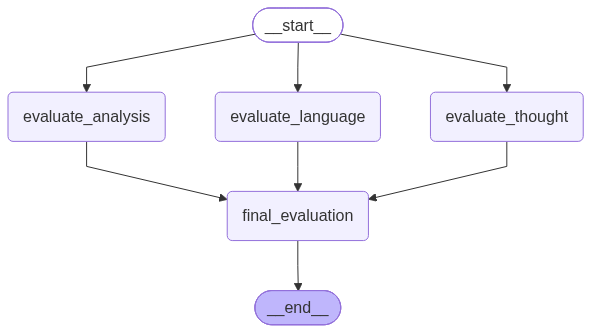

In [4]:
#### 1.3 Import
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

#### Defining class for structured response
class EvaluationSchema(BaseModel):
  feedback: str = Field(description='Detailed feedback for the essay')
  score: int = Field(description='Score out of 10', ge=0, le=10)

## Initialting the llm
model = ChatOllama(model = 'llama3.1')

## Initialting the structured llm
structured_model = model.with_structured_output(EvaluationSchema)

#### Defining graph state
class UPSCState(TypedDict):
  essay: str
  language_feedback: str
  analysis_feedback: str
  clarity_feedback: str
  overall_feedback: str

  individual_scores: Annotated[list[int], operator.add]
  average_score: float


##### Defining the functions
def evaluate_language(state: UPSCState):
  prompt = f'''Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10: \n {state['essay']}'''
  output = structured_model.invoke(prompt)
  return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
  prompt = f'''Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10: \n {state['essay']}'''
  output = structured_model.invoke(prompt)
  return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
  prompt = f'''Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10: \n {state['essay']}'''
  output = structured_model.invoke(prompt)
  return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
  # Summary feedback
  prompt = f'''
  Based on the following feedbacks, generate a summarized feedback: \n
  language_feedback: {state['language_feedback']} \n
  analysis_feedback: {state['analysis_feedback']} \n
  clarity_feedback: {state['clarity_feedback']}
  '''
  overall_feedback = model.invoke(prompt).content

  # Average score
  average_score = sum(state['individual_scores'])/len(state['individual_scores'])

  return {'overall_feedback' : overall_feedback, 'average_score' : average_score}


#### Defining graph
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

#### Compile the worklfow
workflow = graph.compile()
workflow


In [5]:
#### Testing
initial_state = {
    'essay' : '''
    Elon Musk is a visionary entrepreneur and the driving force behind Tesla, a company that has revolutionized the automotive industry. Born in South Africa, Musk joined Tesla in its early days and transformed it into a global leader in electric vehicles. Under his leadership as CEO, Tesla introduced groundbreaking cars like the Model S, Model 3, and Cybertruck, proving that EVs can be high-performing, stylish, and practical. Musk's ultimate goal with Tesla is to accelerate the world's transition to sustainable energy. Despite facing production challenges and skeptics, his relentless drive has made Tesla the most valuable automaker globally recognized today.
Elon Musk is a visionary entrepreneur and the driving force behind Tesla, a company that has revolutionized the automotive industry. Born in South Africa, Musk joined Tesla in its early days and transformed it into a global leader in electric vehicles. Under his leadership as CEO, Tesla introduced groundbreaking cars like the Model S, Model 3, and Cybertruck, proving that EVs can be high-performing, stylish, and practical. Musk's ultimate goal with Tesla is to accelerate the world's transition to sustainable energy. Despite facing production challenges and skeptics, his relentless drive has made Tesla the most valuable automaker globally recognized today.
'''
}

workflow.invoke(initial_state)


{'essay': "\n    Elon Musk is a visionary entrepreneur and the driving force behind Tesla, a company that has revolutionized the automotive industry. Born in South Africa, Musk joined Tesla in its early days and transformed it into a global leader in electric vehicles. Under his leadership as CEO, Tesla introduced groundbreaking cars like the Model S, Model 3, and Cybertruck, proving that EVs can be high-performing, stylish, and practical. Musk's ultimate goal with Tesla is to accelerate the world's transition to sustainable energy. Despite facing production challenges and skeptics, his relentless drive has made Tesla the most valuable automaker globally recognized today.\nElon Musk is a visionary entrepreneur and the driving force behind Tesla, a company that has revolutionized the automotive industry. Born in South Africa, Musk joined Tesla in its early days and transformed it into a global leader in electric vehicles. Under his leadership as CEO, Tesla introduced groundbreaking cars

#### 1.7 Non LLM Based Quadratic Workflow - Conditional Workflow

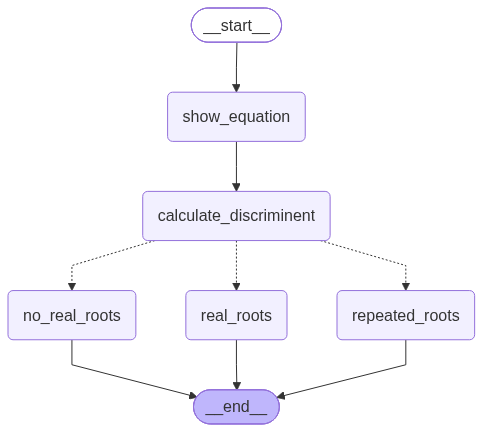

In [14]:
#### Importing libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

#### Defining graph state
class QuadState(TypedDict):
  a: int
  b: int
  c: int
  equation: str
  discriminent: float
  result: str

#### Defining functions
def show_equation(state: QuadState):
  equation = f'{state["a"]}x2+{state["b"]}x+{state["c"]}'
  return {'equation': equation}

def calculate_discriminent(state: QuadState):
  discriminent = (state["b"]**2) - (4 * state["a"]) * (state["c"])
  return {'discriminent' : discriminent}

def real_roots(state: QuadState):
  root1 = (-state["b"]+state["discriminent"]**0.5)/(2*state["a"])
  root2 = (-state["b"]-state["discriminent"]**0.5)/(2*state["a"])
  result = f'The roots are {root1} and {root2}'
  return {'result' : result}

def repeated_roots(state: QuadState):
  root = (-state["b"])/(2*state["a"])
  result = f'The only repeating root is {root}'
  return {'result' : result}

def no_real_roots(state: QuadState):
  result = f'No real roots'
  return {'result' : result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
  if state['discriminent'] > 0:
    return "real_roots"
  elif state['discriminent'] == 0:
    return "repeated_roots"
  else:
    return "no_real_roots"

#### Defining graph
graph = StateGraph(QuadState)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminent", calculate_discriminent)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)


graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminent")
graph.add_conditional_edges("calculate_discriminent", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()
workflow

In [18]:
initial_state = {
    'a': 2,
    'b': 4,
    'c': 1
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 1,
 'equation': '2x2+4x+1',
 'discriminent': 8,
 'result': 'The roots are -0.2928932188134524 and -1.7071067811865475'}